In [1]:
import numpy as np

import sys
sys.path.append("..")
import data_generation
import torch
import matplotlib.pyplot as plt
import ml_solver
import pde
import numerical_solver

# 1D Hierarchical Gaussian Random Field

In [2]:
device = torch.device("cpu")
grf = data_generation.GaussianRandomFieldHierarchical(dim=1, num_samples=33, alpha_min=0.09, alpha_max= 9, beta_min=9, beta_max= 50, gamma_list=[1.5, 2.5, 3.5], device = device)
n_samples = 4
a = grf.generate(n_samples)

f = grf.generate(n_samples, pushfoward = None)
k2 = grf.generate(n_samples)

## Create an equation object (Helmholtz)

In [3]:
equation = pde.HelmholtzEquation1D(a_func = a, f_func = f, boundary='Dirichlet', x = torch.linspace(0, 1, 33), k2 = k2)

## Visualize the solutions 

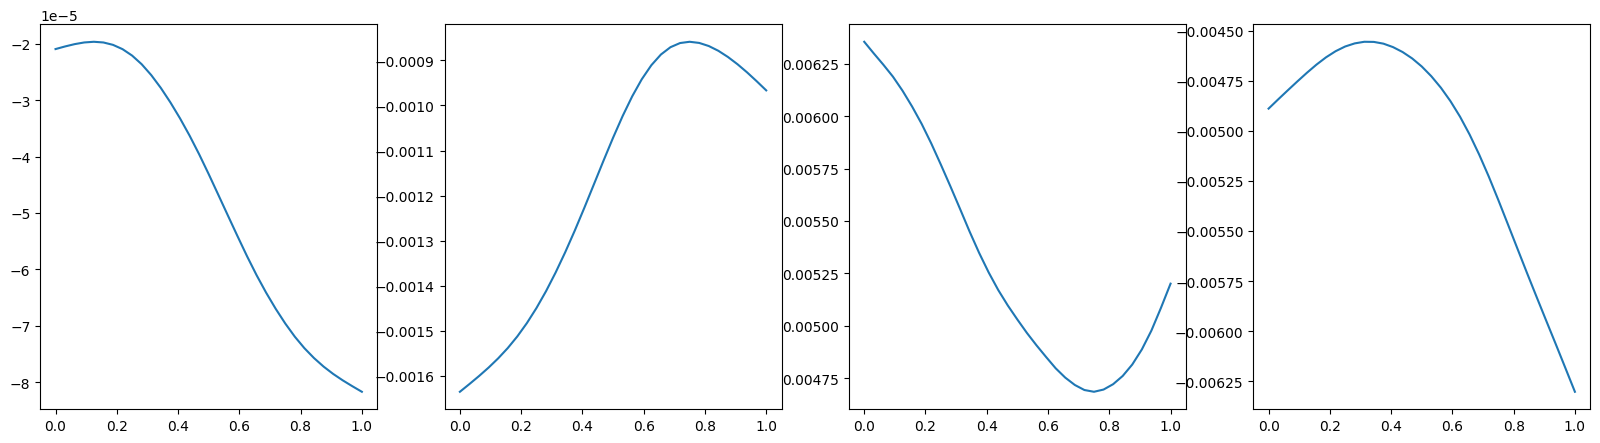

In [4]:
fig, ax = plt.subplots(ncols = n_samples)
for i in range(n_samples):
    ax[i].plot(np.linspace(0, 1, 33), equation.u[i].detach().numpy())
height = 5
fig.set_figheight(5)
fig.set_figwidth(n_samples*height)

## Use a numerical solver

In [7]:
solver = numerical_solver.WeightedJacobiSolver(equation)
sol = solver.batch_solve() # Default: tol=1e-10, max_iter=1000,
print(sol.shape)

Iteration 0, converged samples: 0/4
Iteration 1, converged samples: 0/4
Iteration 2, converged samples: 0/4
Iteration 3, converged samples: 0/4
Iteration 4, converged samples: 0/4
Iteration 5, converged samples: 0/4
Iteration 6, converged samples: 0/4
Iteration 7, converged samples: 0/4
Iteration 8, converged samples: 0/4
Iteration 9, converged samples: 0/4
Iteration 10, converged samples: 0/4
Iteration 11, converged samples: 0/4
Iteration 12, converged samples: 0/4
Iteration 13, converged samples: 0/4
Iteration 14, converged samples: 0/4
Iteration 15, converged samples: 0/4
Iteration 16, converged samples: 0/4
Iteration 17, converged samples: 0/4
Iteration 18, converged samples: 0/4
Iteration 19, converged samples: 0/4
Iteration 20, converged samples: 0/4
Iteration 21, converged samples: 0/4
Iteration 22, converged samples: 0/4
Iteration 23, converged samples: 0/4
Iteration 24, converged samples: 0/4
Iteration 25, converged samples: 0/4
Iteration 26, converged samples: 0/4
Iteration 2

## Compute residual of the solution

In [10]:
residual = equation.compute_residual(sol)
print(residual.shape)

torch.Size([4, 33])


# 2D Gaussian Random Field

In [15]:
grf = data_generation.GaussianRandomField(dim=2, num_samples=33, alpha = 1, beta=9, gamma = 2.0, device = device)
n_samples = 4
a = grf.generate(n_samples)
f = grf.generate(n_samples, pushfoward = None)

## Create an equation object (Poisson)

In [23]:
equation2d = pde.PoissonEquation2D(a_func = a.reshape((n_samples, -1)), f_func = f.reshape((n_samples, -1)), boundary='Periodic', x = torch.linspace(0, 1, 33), y = torch.linspace(0, 1, 33))

# Visualize the solutions

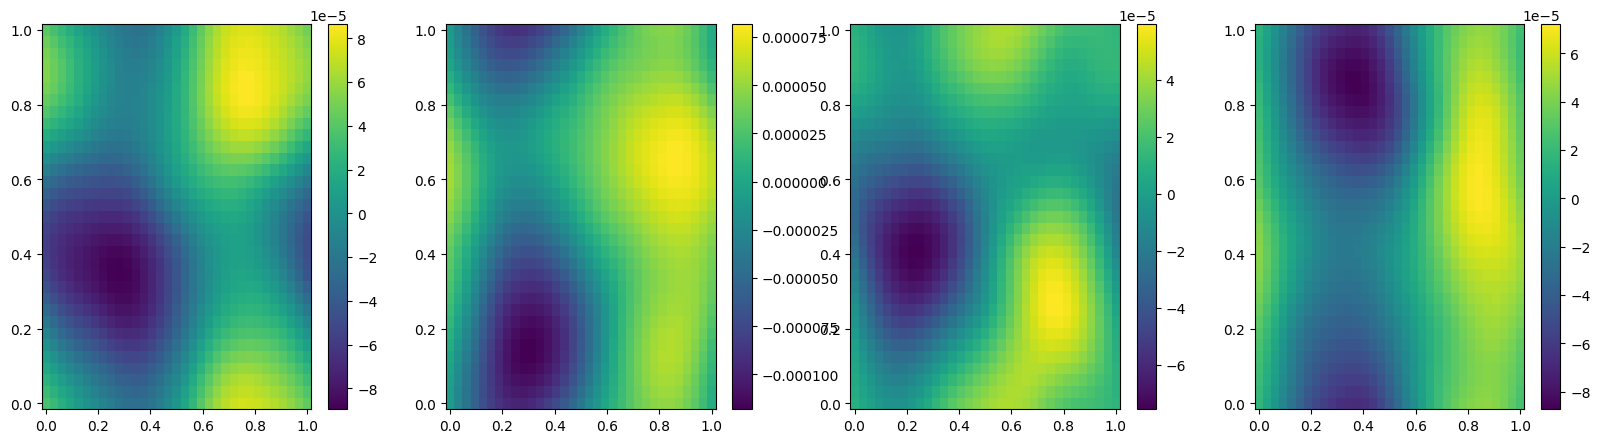

In [24]:
fig, ax = plt.subplots(ncols = n_samples)
for i in range(n_samples):
    x = np.linspace(0, 1, 33)
    y = np.linspace(0, 1, 33)
    x, y = np.meshgrid(x, y)
    z = ax[i].pcolormesh(x, y, equation2d.u[i].detach().numpy())
    plt.colorbar(z, ax=ax[i])
height = 5
fig.set_figheight(5)
fig.set_figwidth(n_samples*height)

## Use a numerical solver

In [25]:
solver = numerical_solver.WeightedJacobiSolver(equation2d)
sol = solver.batch_solve() # Default: tol=1e-10, max_iter=1000,
print(sol.shape)

Iteration 0, converged samples: 0/4
Iteration 1, converged samples: 0/4
Iteration 2, converged samples: 0/4
Iteration 3, converged samples: 0/4
Iteration 4, converged samples: 0/4
Iteration 5, converged samples: 0/4
Iteration 6, converged samples: 0/4
Iteration 7, converged samples: 0/4
Iteration 8, converged samples: 0/4
Iteration 9, converged samples: 0/4
Iteration 10, converged samples: 0/4
Iteration 11, converged samples: 0/4
Iteration 12, converged samples: 0/4
Iteration 13, converged samples: 0/4
Iteration 14, converged samples: 0/4
Iteration 15, converged samples: 0/4
Iteration 16, converged samples: 0/4
Iteration 17, converged samples: 0/4
Iteration 18, converged samples: 0/4
Iteration 19, converged samples: 0/4
Iteration 20, converged samples: 0/4
Iteration 21, converged samples: 0/4
Iteration 22, converged samples: 0/4
Iteration 23, converged samples: 0/4
Iteration 24, converged samples: 0/4
Iteration 25, converged samples: 0/4
Iteration 26, converged samples: 0/4
Iteration 2

## Compute residual of the solution 

In [26]:
residual = equation.compute_residual(sol) # the solutions need to be in its 1D representation
print(residual.shape)

torch.Size([4, 1089])
